In [4]:
!pip install torch torchvision
!pip install git+https://github.com/openai/CLIP.git
!pip install matplotlib tqdm


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Cloning https://github.com/openai/CLIP.git to c:\users\phamt\appdata\local\temp\pip-req-build-g6d_dkvs
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git 'C:\Users\phamt\AppData\Local\Temp\pip-req-build-g6d_dkvs'

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import torch
import clip
from PIL import Image
from torchvision.datasets import STL10


device = "cuda" if torch.cuda.is_available() else "cpu"

model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()

CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          

In [6]:
dataset = STL10(root="./data", split="test", download=True)

classes = dataset.classes
texts = [f"a photo of a {c}" for c in classes]

text_tokens = clip.tokenize(texts).to(device)

with torch.no_grad():
    text_features = model.encode_text(text_tokens)
    text_features /= text_features.norm(dim=-1, keepdim=True)

100%|██████████| 2.64G/2.64G [16:25<00:00, 2.68MB/s]   


Extracting ./data\stl10_binary.tar.gz to ./data


### Image–Text Matching

=== Image-Text Matching ===


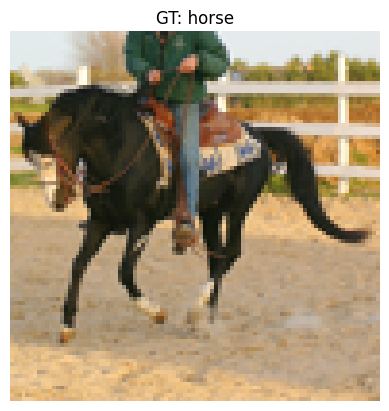


Similarity scores:
a photo of a airplane    : 0.0969
a photo of a bird        : 0.0997
a photo of a car         : 0.0988
a photo of a cat         : 0.1005
a photo of a deer        : 0.0994
a photo of a dog         : 0.1009
a photo of a horse       : 0.1069
a photo of a monkey      : 0.1002
a photo of a ship        : 0.0974
a photo of a truck       : 0.0994

Prediction: horse


In [8]:
import matplotlib.pyplot as plt
print("=== Image-Text Matching ===")

image, label = dataset[0]

plt.imshow(image)
plt.title(f"GT: {classes[label]}")
plt.axis("off")
plt.show()

image_input = preprocess(image).unsqueeze(0).to(device)

with torch.no_grad():
    image_features = model.encode_image(image_input)
    image_features /= image_features.norm(dim=-1, keepdim=True)

    similarity = (image_features @ text_features.T).squeeze(0)
    probs = similarity.softmax(dim=0)

print("\nSimilarity scores:")
for t, p in zip(texts, probs):
    print(f"{t:25s}: {p.item():.4f}")

pred = similarity.argmax().item()
print("\nPrediction:", classes[pred])

### Zero-shot Classification


=== Zero-shot Classification (Debug + Show Image) ===


  0%|          | 0/10 [00:00<?, ?it/s]

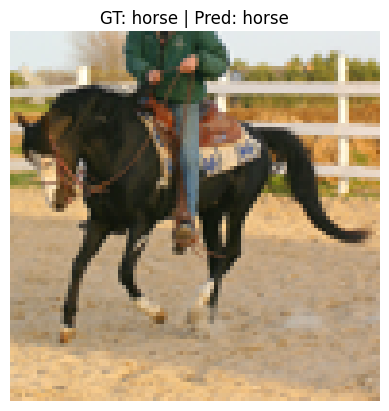


Sample 0
Ground Truth: horse

Image embedding (first 10 dims):
[-0.00433   0.02217   0.003036  0.01695   0.05014  -0.0559    0.01035
 -0.02899   0.01186   0.0096  ]

Similarity scores:
airplane       : 0.1558
bird           : 0.1844
car            : 0.1758
cat            : 0.1925
deer           : 0.1819
dog            : 0.1967
horse          : 0.2551
monkey         : 0.1896
ship           : 0.1617
truck          : 0.1824

Probabilities:
airplane       : 0.0969
bird           : 0.0997
car            : 0.0988
cat            : 0.1005
deer           : 0.0994
dog            : 0.1009
horse          : 0.1069
monkey         : 0.1002
ship           : 0.0974
truck          : 0.0994

Prediction vs Ground Truth:
GT   : horse
Pred : horse
Correct


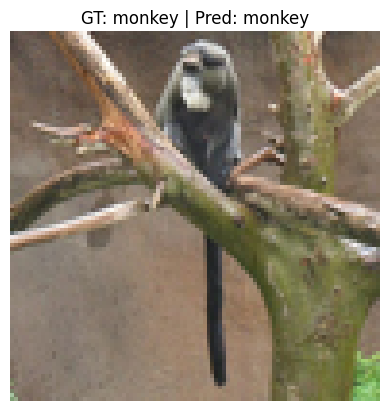


Sample 1
Ground Truth: monkey

Image embedding (first 10 dims):
[-0.0085     0.0271    -0.0002103 -0.023      0.003258  -0.01682
  0.011765  -0.002674   0.02574    0.04587  ]

Similarity scores:
airplane       : 0.1757
bird           : 0.2620
car            : 0.1975
cat            : 0.2318
deer           : 0.2041
dog            : 0.2288
horse          : 0.2212
monkey         : 0.3069
ship           : 0.1984
truck          : 0.1971

Probabilities:
airplane       : 0.0954
bird           : 0.1039
car            : 0.0975
cat            : 0.1009
deer           : 0.0981
dog            : 0.1006
horse          : 0.0998
monkey         : 0.1088
ship           : 0.0976
truck          : 0.0975

Prediction vs Ground Truth:
GT   : monkey
Pred : monkey
Correct


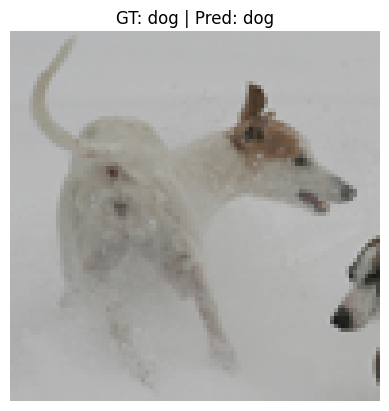


Sample 2
Ground Truth: dog

Image embedding (first 10 dims):
[-0.013504  -0.000851  -0.003202   0.0652     0.0008006 -0.04468
  0.05432    0.000542   0.03038    0.0006886]

Similarity scores:
airplane       : 0.1698
bird           : 0.1815
car            : 0.1882
cat            : 0.1979
deer           : 0.2128
dog            : 0.2563
horse          : 0.2095
monkey         : 0.1887
ship           : 0.1747
truck          : 0.1899

Probabilities:
airplane       : 0.0973
bird           : 0.0984
car            : 0.0991
cat            : 0.1000
deer           : 0.1016
dog            : 0.1061
horse          : 0.1013
monkey         : 0.0992
ship           : 0.0978
truck          : 0.0993

Prediction vs Ground Truth:
GT   : dog
Pred : dog
Correct


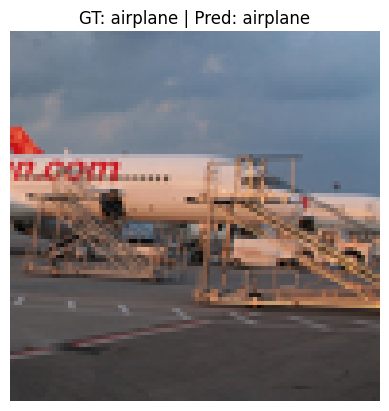

 40%|████      | 4/10 [00:00<00:00, 30.58it/s]


Sample 3
Ground Truth: airplane

Image embedding (first 10 dims):
[ 0.00806  0.00625 -0.0269   0.07135  0.0465  -0.01997  0.02316 -0.01624
 -0.01634  0.04254]

Similarity scores:
airplane       : 0.2391
bird           : 0.1876
car            : 0.1920
cat            : 0.1741
deer           : 0.1608
dog            : 0.1758
horse          : 0.1733
monkey         : 0.1860
ship           : 0.1974
truck          : 0.1774

Probabilities:
airplane       : 0.1054
bird           : 0.1001
car            : 0.1005
cat            : 0.0988
deer           : 0.0975
dog            : 0.0989
horse          : 0.0987
monkey         : 0.1000
ship           : 0.1011
truck          : 0.0991

Prediction vs Ground Truth:
GT   : airplane
Pred : airplane
Correct


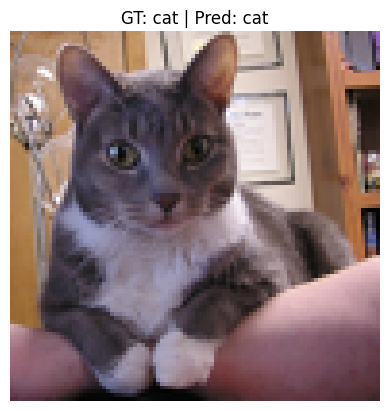


Sample 4
Ground Truth: cat

Image embedding (first 10 dims):
[-2.8275e-02 -2.3575e-03 -8.6288e-03  1.4565e-02  9.4843e-04 -2.8372e-05
  1.1276e-02  8.8348e-03  1.7212e-02 -1.7746e-02]

Similarity scores:
airplane       : 0.1697
bird           : 0.2010
car            : 0.1820
cat            : 0.2649
deer           : 0.1844
dog            : 0.2200
horse          : 0.1968
monkey         : 0.2076
ship           : 0.1907
truck          : 0.1910

Probabilities:
airplane       : 0.0969
bird           : 0.1000
car            : 0.0981
cat            : 0.1066
deer           : 0.0983
dog            : 0.1019
horse          : 0.0995
monkey         : 0.1006
ship           : 0.0989
truck          : 0.0990

Prediction vs Ground Truth:
GT   : cat
Pred : cat
Correct


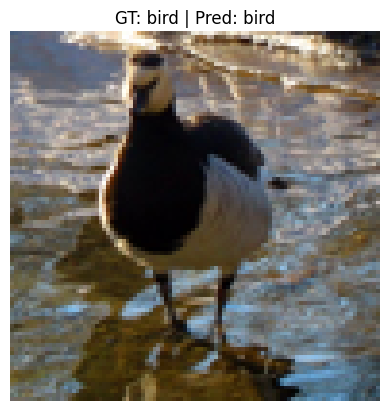


Sample 5
Ground Truth: bird

Image embedding (first 10 dims):
[ 0.03836   0.0297    0.01406   0.006126  0.02423  -0.02805   0.0408
  0.01333   0.05673   0.03134 ]

Similarity scores:
airplane       : 0.1825
bird           : 0.2842
car            : 0.1874
cat            : 0.2134
deer           : 0.2233
dog            : 0.2321
horse          : 0.2245
monkey         : 0.2076
ship           : 0.1930
truck          : 0.1952

Probabilities:
airplane       : 0.0968
bird           : 0.1072
car            : 0.0973
cat            : 0.0999
deer           : 0.1008
dog            : 0.1017
horse          : 0.1010
monkey         : 0.0993
ship           : 0.0978
truck          : 0.0981

Prediction vs Ground Truth:
GT   : bird
Pred : bird
Correct


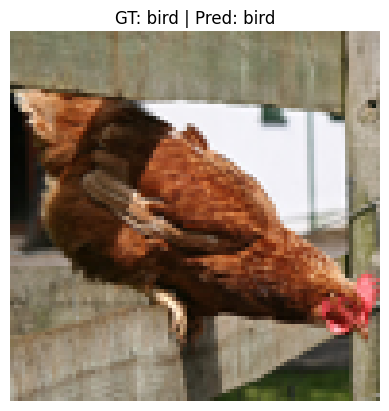


Sample 6
Ground Truth: bird

Image embedding (first 10 dims):
[ 0.03128  -0.002428  0.00976   0.006355  0.003986 -0.0164    0.03784
  0.02118   0.01347   0.03806 ]

Similarity scores:
airplane       : 0.1660
bird           : 0.2460
car            : 0.1874
cat            : 0.2028
deer           : 0.1764
dog            : 0.2126
horse          : 0.2148
monkey         : 0.1826
ship           : 0.1807
truck          : 0.2004

Probabilities:
airplane       : 0.0969
bird           : 0.1050
car            : 0.0990
cat            : 0.1005
deer           : 0.0980
dog            : 0.1016
horse          : 0.1018
monkey         : 0.0986
ship           : 0.0983
truck          : 0.1003

Prediction vs Ground Truth:
GT   : bird
Pred : bird
Correct


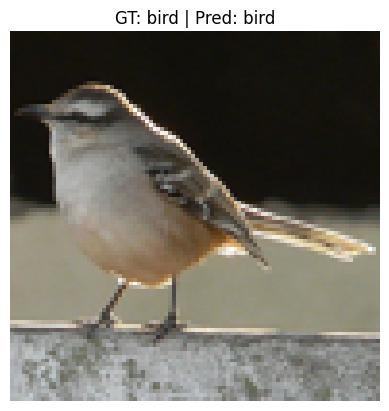

 80%|████████  | 8/10 [00:00<00:00, 29.98it/s]


Sample 7
Ground Truth: bird

Image embedding (first 10 dims):
[ 0.01875    0.04883   -0.0306    -0.0336    -0.01087    0.03345
  0.0455    -0.0005307 -0.009865   0.01732  ]

Similarity scores:
airplane       : 0.1855
bird           : 0.2922
car            : 0.1901
cat            : 0.2103
deer           : 0.1898
dog            : 0.2120
horse          : 0.1871
monkey         : 0.1931
ship           : 0.1984
truck          : 0.1949

Probabilities:
airplane       : 0.0980
bird           : 0.1090
car            : 0.0984
cat            : 0.1005
deer           : 0.0984
dog            : 0.1006
horse          : 0.0981
monkey         : 0.0988
ship           : 0.0992
truck          : 0.0989

Prediction vs Ground Truth:
GT   : bird
Pred : bird
Correct


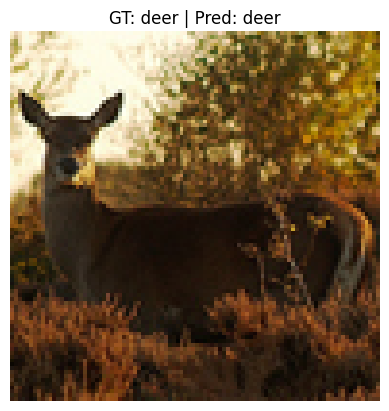


Sample 8
Ground Truth: deer

Image embedding (first 10 dims):
[-0.02708   0.010414 -0.013115 -0.00711   0.001487  0.01168   0.02075
 -0.00826   0.04382   0.02359 ]

Similarity scores:
airplane       : 0.1691
bird           : 0.2212
car            : 0.1951
cat            : 0.2097
deer           : 0.2903
dog            : 0.2291
horse          : 0.2266
monkey         : 0.2104
ship           : 0.1868
truck          : 0.1936

Probabilities:
airplane       : 0.0956
bird           : 0.1008
car            : 0.0981
cat            : 0.0996
deer           : 0.1080
dog            : 0.1016
horse          : 0.1013
monkey         : 0.0997
ship           : 0.0974
truck          : 0.0980

Prediction vs Ground Truth:
GT   : deer
Pred : deer
Correct


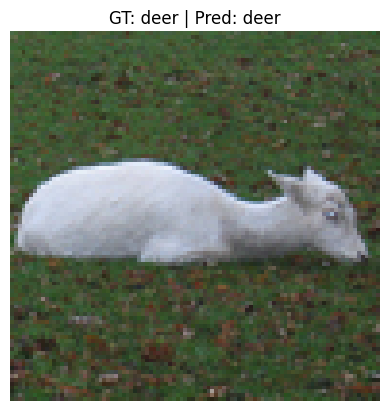

100%|██████████| 10/10 [00:00<00:00, 28.98it/s]


Sample 9
Ground Truth: deer

Image embedding (first 10 dims):
[ 0.004574   0.0002506 -0.003319   0.051      0.01767   -0.01152
  0.01947   -0.003752   0.002434   0.01952  ]

Similarity scores:
airplane       : 0.1959
bird           : 0.2258
car            : 0.2094
cat            : 0.2361
deer           : 0.2710
dog            : 0.2517
horse          : 0.2542
monkey         : 0.2123
ship           : 0.2000
truck          : 0.2017

Probabilities:
airplane       : 0.0970
bird           : 0.1000
car            : 0.0983
cat            : 0.1010
deer           : 0.1046
dog            : 0.1026
horse          : 0.1028
monkey         : 0.0986
ship           : 0.0974
truck          : 0.0976

Prediction vs Ground Truth:
GT   : deer
Pred : deer
Correct

Final Accuracy: 1.0


In [9]:
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

print("\n=== Zero-shot Classification (Debug + Show Image) ===")

correct = 0
total = 10

for i in tqdm(range(total)):
    image, label = dataset[i]
    image_input = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        # ===== ENCODE =====
        image_features = model.encode_image(image_input)
        image_features /= image_features.norm(dim=-1, keepdim=True)

        similarity = (image_features @ text_features.T).squeeze(0)
        probs = similarity.softmax(dim=0)

    pred = similarity.argmax().item()

    # ===== SHOW IMAGE =====
    plt.imshow(image)
    plt.title(f"GT: {dataset.classes[label]} | Pred: {dataset.classes[pred]}")
    plt.axis("off")
    plt.show()

    # ===== PRINT INFO =====
    print("\n" + "="*60)
    print(f"Sample {i}")
    print("Ground Truth:", dataset.classes[label])

    # embedding (rút gọn)
    print("\nImage embedding (first 10 dims):")
    print(image_features[0][:10].cpu().numpy())

    # similarity
    print("\nSimilarity scores:")
    for cls, score in zip(dataset.classes, similarity):
        print(f"{cls:15s}: {score.item():.4f}")

    # probability
    print("\nProbabilities:")
    for cls, p in zip(dataset.classes, probs):
        print(f"{cls:15s}: {p.item():.4f}")

    # prediction
    print("\nPrediction vs Ground Truth:")
    print("GT   :", dataset.classes[label])
    print("Pred :", dataset.classes[pred])

    if pred == label:
        print("Correct")
        correct += 1
    else:
        print("Wrong")

# ===== FINAL =====
print("\n" + "="*60)
print("Final Accuracy:", correct / total)

### Image Retrieval (Text → Image)


=== Image Retrieval ===


100%|██████████| 300/300 [00:03<00:00, 96.71it/s] 


Top-5 indices: tensor([213,  23, 205, 129,  21], device='cuda:0')


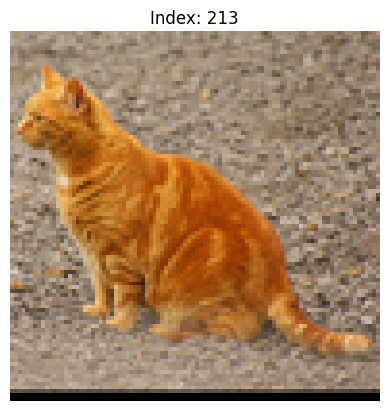

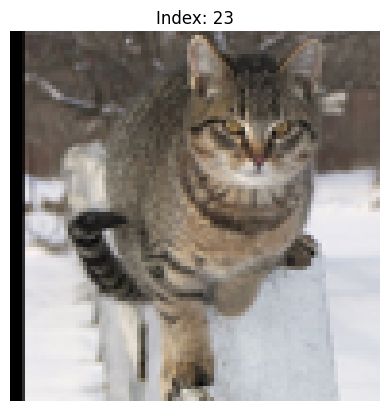

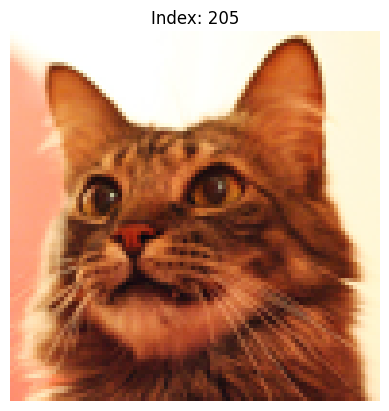

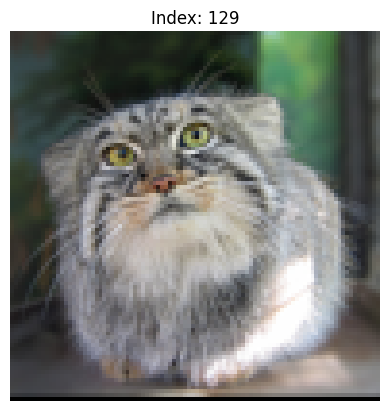

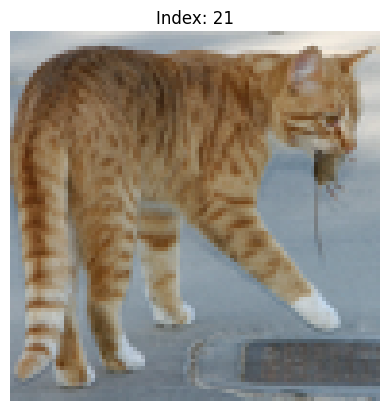

In [ ]:
print("\n=== Image Retrieval ===")

# encode images
image_features_list = []

subset_size = 300

for i in tqdm(range(subset_size)):
    img, _ = dataset[i]
    img_input = preprocess(img).unsqueeze(0).to(device)

    with torch.no_grad():
        feat = model.encode_image(img_input)
        feat /= feat.norm(dim=-1, keepdim=True)
        image_features_list.append(feat)

image_features = torch.cat(image_features_list)

# query
# query = "a photo of a cat"
query = "a photo of a dog"
text = clip.tokenize([query]).to(device)

with torch.no_grad():
    text_feature = model.encode_text(text)
    text_feature /= text_feature.norm(dim=-1, keepdim=True)

similarity = (text_feature @ image_features.T).squeeze(0)
topk = similarity.topk(5)

print("Top-5 indices:", topk.indices)

# visualize
for idx in topk.indices:
    img, _ = dataset[idx]
    plt.imshow(img)
    plt.title(f"Index: {idx}")
    plt.axis("off")
    plt.show()

### Text Retrieval (Image → Text)


=== Text Retrieval ===


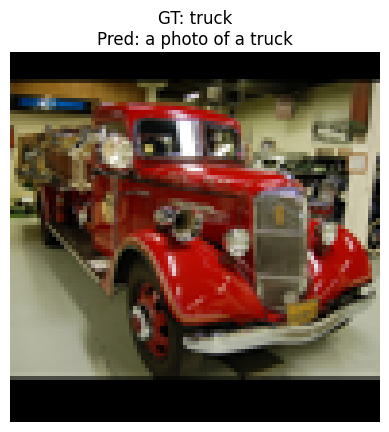

Best caption: a photo of a truck

Top-3 captions:
a photo of a truck  (0.2201)
a photo of a car  (0.2123)
a photo of a ship  (0.1740)


In [ ]:
import matplotlib.pyplot as plt

print("\n=== Text Retrieval ===")

image, label = dataset[17]
image_input = preprocess(image).unsqueeze(0).to(device)

candidate_texts = texts
text_tokens = clip.tokenize(candidate_texts).to(device)

with torch.no_grad():
    image_feature = model.encode_image(image_input)
    text_features = model.encode_text(text_tokens)

    image_feature /= image_feature.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

similarity = (image_feature @ text_features.T).squeeze(0)

# ===== Prediction =====
best_idx = similarity.argmax().item()

# ===== Top-k =====
topk = similarity.topk(3)

# ===== SHOW IMAGE =====
plt.imshow(image)
plt.title(
    f"GT: {dataset.classes[label]}\n"
    f"Pred: {candidate_texts[best_idx]}"
)
plt.axis("off")
plt.show()

# ===== PRINT TEXT =====
print("Best caption:", candidate_texts[best_idx])

print("\nTop-3 captions:")
for idx in topk.indices:
    print(f"{candidate_texts[idx]}  ({similarity[idx].item():.4f})")